# Matching experimental rates with a Poisson target

`maxcal-target` reweights first-passage times so that they reproduce **experimental rate constants** and a **single-exponential (Poisson) shape**. The weights are the product: applied to structural observables, they show which trajectories — and which mechanisms — the experimental kinetics favour.

This notebook uses the same dataset as the regression test (`tests/synthetic.py: write_rate_dataset`): twelve PDZ2-like systems (two peptides × WT + five mutants) with the experimental k_on/k_off of the reference measurements and model rates taken from a multi-eGO study, with seeded exponential times standing in for the real per-trajectory times. Point it at your own `systems.csv` to use real data.

1. **Data** — experimental vs model rates.
2. **Clock calibration** — one global factor; what is left per system.
3. **Weights** — model, reweighted and target CDFs, per system and direction.
4. **Cost** — N_eff versus the needed change.
5. **Using the weights** — a structural observable, weighted vs unweighted.
6. **K_D** — the affinity scatter before and after reweighting.

Sliders need `ipywidgets`; without it each interactive cell shows static figures. They recompute when released.

In [1]:
%matplotlib inline
import os, sys, importlib, inspect
import numpy as np
import matplotlib.pyplot as plt

ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir)) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path[:0] = [ROOT, os.path.join(ROOT, "tests")]
import maxcal.target as mt
import synthetic as S
for _m in (mt, S):
    importlib.reload(_m)
if not hasattr(S, "write_rate_dataset"):
    raise ImportError("tests/synthetic.py has no write_rate_dataset: update the repository "
                      "and restart the kernel")

try:
    import ipywidgets as W
    HAVE_WIDGETS = not os.environ.get("MAXCAL_DEMO_STATIC")
except ImportError:
    HAVE_WIDGETS = False

def explore(fn, static, **controls):
    if not HAVE_WIDGETS:
        for kw in static:
            fn(**kw)
        return
    defaults = {k: v.default for k, v in inspect.signature(fn).parameters.items()}
    def widget(name, spec):
        if isinstance(spec, list):
            return W.Dropdown(options=spec, value=defaults[name], description=name)
        lo, hi, step = spec
        return W.FloatSlider(min=lo, max=hi, step=step, value=defaults[name], description=name,
                             continuous_update=False, style={"description_width": "initial"})
    ws = {k: widget(k, v) for k, v in controls.items() if v is not None}
    status, out = W.HTML(), W.Output()
    def run(**kw):
        status.value = "<i>computing…</i>"
        with out:
            out.clear_output(wait=True); fn(**kw)
        status.value = ""
    W.interactive_output(run, ws)
    display(W.VBox([W.HBox(list(ws.values())), status, out]))

plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3})
CONC = 0.017          # M, peptide concentration in the simulations
print("widgets:", HAVE_WIDGETS)

widgets: False


## 1. The data

Each system contributes 50 binding and 50 unbinding first-passage times (in ps) plus its experimental k_on and k_off. `maxcal-target` reads exactly this: a `systems.csv` pointing at one file of times per system and direction.

In [2]:
import tempfile
DATA = tempfile.mkdtemp()
SYSTEMS_CSV = S.write_rate_dataset(DATA, n=50, seed=7)
systems = mt.read_systems(SYSTEMS_CSV)
print(open(SYSTEMS_CSV).read().split("\n")[0])
print(open(SYSTEMS_CSV).read().split("\n")[1], "\n")
print(f"{'system':14s} {'kon_exp':>8s} {'koff_exp':>9s} {'tau_bind (ps)':>14s} {'tau_unbind (ps)':>16s}")
for s in systems:
    print(f"{s['name']:14s} {s['kon']:8.2f} {s['koff']:9.1f} {s['t_bind'].mean():14.0f} "
          f"{s['t_unbind'].mean():16.0f}")

system,kon_exp,koff_exp,bind_times,unbind_times
EQVSAV_A53G,2.78,43.0,times/EQVSAV_A53G_bind.dat,times/EQVSAV_A53G_unbind.dat 

system          kon_exp  koff_exp  tau_bind (ps)  tau_unbind (ps)
EQVSAV_A53G        2.78      43.0            637           769000
EQVSAV_L18A        2.20      13.8            560           909000
EQVSAV_L25A        1.69      37.7            612           312000
EQVSAV_T35G        3.10      81.0            446           435000
EQVSAV_V44A        3.30      30.0            595           714000
EQVSAV_WT          2.90      26.0            525           435000
EQVTAV_A53G        2.40      21.0            490          1250000
EQVTAV_L18A        2.40      10.4            520          1430000
EQVTAV_L25A        1.12      53.8            533           526000
EQVTAV_T35G        2.70      49.0            592          1000000
EQVTAV_V44A        2.70      23.0            532          1110000
EQVTAV_WT          2.60      22.0            391           909000


## 2. Clock calibration

The model is orders of magnitude faster than experiment, so comparing rates directly is meaningless. For every system and direction the script forms **A = k_model / k_exp** and fits **one global clock factor c** across all of them. What is left, **A/c**, is the per-system error the reweighting has to absorb.

The choice of c is a free calibration and it matters, because slowing a sample down is cheap and speeding it up is not: for an exponential sample, changing the mean by a factor f keeps N_eff/N ≈ 2f − f², and **f = 2 is a hard limit**.

- `geometric` — geometric mean of A;
- `decrease-only` — the largest A, so every system needs a slowdown;
- `balanced` (default) — maximises the worst-case N_eff.

geometric      c = 4.594e-08   factors 0.44–2.14   worst N_eff/N = -0.31
decrease-only  c = 9.854e-08   factors 0.21–1.00   worst N_eff/N = 0.37
balanced       c = 5.956e-08   factors 0.34–1.65   worst N_eff/N = 0.57


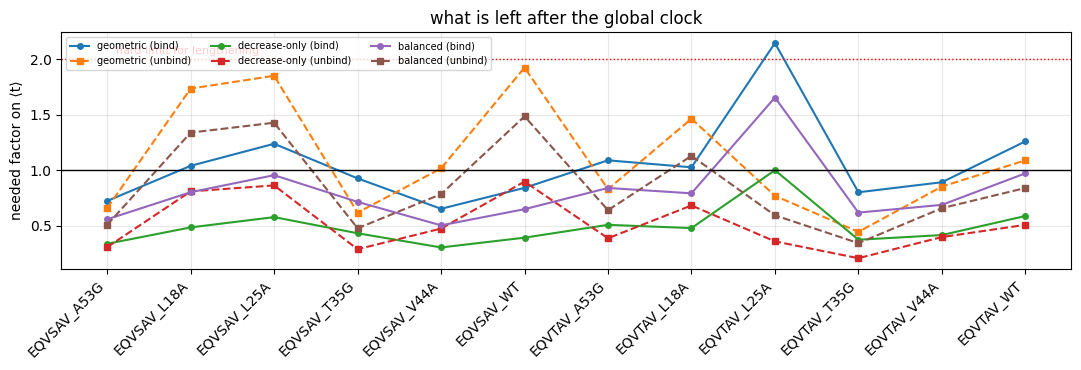

In [3]:
A = mt.acceleration(systems, CONC, "binding")
names = [s["name"] for s in systems]
clocks = {m: mt.choose_clock(A, m) for m in ("geometric", "decrease-only", "balanced")}
for m, c in clocks.items():
    f = np.array([a / c for pair in A.values() for a in pair])
    print(f"{m:14s} c = {c:.3e}   factors {f.min():.2f}–{f.max():.2f}   "
          f"worst N_eff/N = {min(mt.neff_fraction(x) for x in f):.2f}")

fig, ax = plt.subplots(figsize=(11, 3.8))
x = np.arange(len(names))
for k, (m, c) in enumerate(clocks.items()):
    ax.plot(x, [A[n][0] / c for n in names], "o-", ms=4, label=f"{m} (bind)")
    ax.plot(x, [A[n][1] / c for n in names], "s--", ms=4, label=f"{m} (unbind)")
ax.axhline(1, color="k", lw=1); ax.axhline(2, color="r", ls=":", lw=1)
ax.text(0.1, 2.05, "hard limit for lengthening", color="r", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(names, rotation=45, ha="right")
ax.set_ylabel("needed factor on ⟨t⟩"); ax.legend(fontsize=7, ncol=3)
ax.set_title("what is left after the global clock"); plt.tight_layout(); plt.show()

## 3. The weights

With the clock fixed, each system and direction has a fully specified target: an exponential whose mean is the experimental one in model time units. Two ways to get there:

- **`target`** (default): w ∝ f_target/f_model, with f_model a gamma fitted to the times. Both the mean and the exponential shape are imposed, and a final tilt matches the mean exactly.
- **`mean`**: w ∝ exp(−θt), the maximum-entropy solution with only the mean constrained.

Pick a system and watch the CDFs and the weights. `tail_gap` is the target mass beyond the longest observed time: the honest limit on how much slower the target can be.

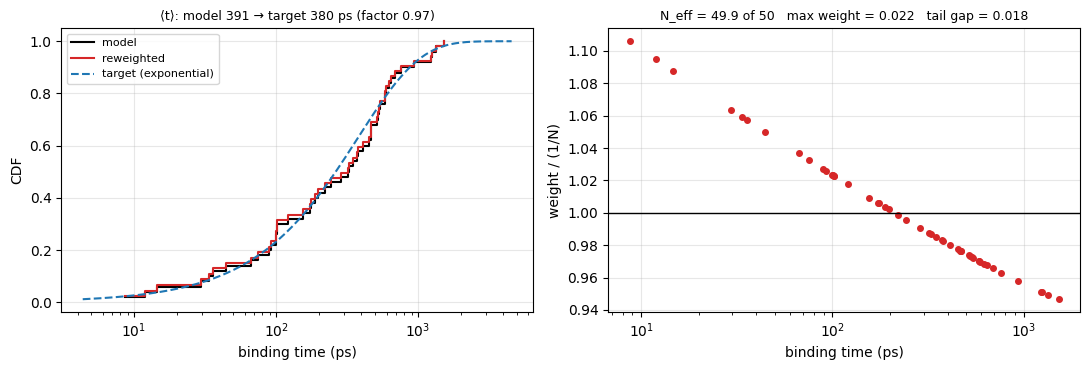

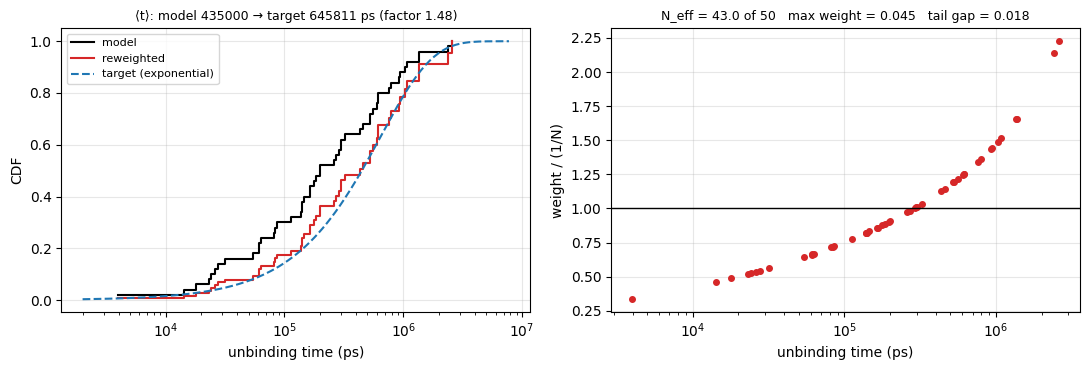

target unreachable with the 'mean' mode (outside the observed range)


In [4]:
CLOCK = mt.choose_clock(A, "balanced")
BY_NAME = {s["name"]: s for s in systems}

def show_system(system="EQVTAV_WT", direction=0.0, mode=0.0):
    s = BY_NAME[system]
    d = "bind" if direction < 0.5 else "unbind"
    t = s["t_bind"] if d == "bind" else s["t_unbind"]
    a = A[system][0 if d == "bind" else 1]
    tau_target = t.mean() * a / CLOCK
    w = (mt.target_weights(t, tau_target) if mode < 0.5 else mt.mean_weights(t, tau_target))
    if w is None:
        print("target unreachable with the 'mean' mode (outside the observed range)"); return
    diag = mt.diagnostics(t, w, tau_target)
    fig, axs = plt.subplots(1, 2, figsize=(11, 3.8))
    o = np.argsort(t); ts = t[o]
    axs[0].step(ts, np.arange(1, ts.size + 1) / ts.size, where="post", color="k", label="model")
    axs[0].step(ts, np.cumsum(w[o]), where="post", color="C3", label="reweighted")
    xx = np.logspace(np.log10(ts.min() / 2), np.log10(ts.max() * 3), 200)
    axs[0].plot(xx, 1 - np.exp(-xx / tau_target), "--", color="C0", label="target (exponential)")
    axs[0].set_xscale("log"); axs[0].set_xlabel(f"{d}ing time (ps)"); axs[0].set_ylabel("CDF")
    axs[0].legend(fontsize=8)
    axs[0].set_title(f"⟨t⟩: model {t.mean():.0f} → target {tau_target:.0f} ps "
                     f"(factor {a / CLOCK:.2f})", fontsize=9)
    axs[1].semilogx(ts, w[o] * w.size, "o", ms=4, color="C3")
    axs[1].axhline(1, color="k", lw=1)
    axs[1].set_xlabel(f"{d}ing time (ps)"); axs[1].set_ylabel("weight / (1/N)")
    axs[1].set_title(f"N_eff = {diag['neff']:.1f} of {t.size}   max weight = "
                     f"{diag['w_max']:.3f}   tail gap = {diag['tail_gap']:.3f}", fontsize=9)
    plt.tight_layout(); plt.show()

explore(show_system,
        static=[dict(system="EQVTAV_WT", direction=0.0, mode=0.0),
                dict(system="EQVSAV_WT", direction=1.0, mode=0.0),
                dict(system="EQVSAV_WT", direction=1.0, mode=1.0)],
        system=names,
        direction=(0.0, 1.0, 1.0) if HAVE_WIDGETS else None,   # 0 = bind, 1 = unbind
        mode=(0.0, 1.0, 1.0) if HAVE_WIDGETS else None)        # 0 = target, 1 = mean

## 4. What the correction costs

For an exponential sample the effective sample size after changing the mean by a factor f is N_eff/N ≈ 2f − f², independent of N. The points are the 24 system/direction pairs; the curve is that formula. Lengthening is expensive and impossible beyond f = 2, which is why the clock is chosen to avoid it.

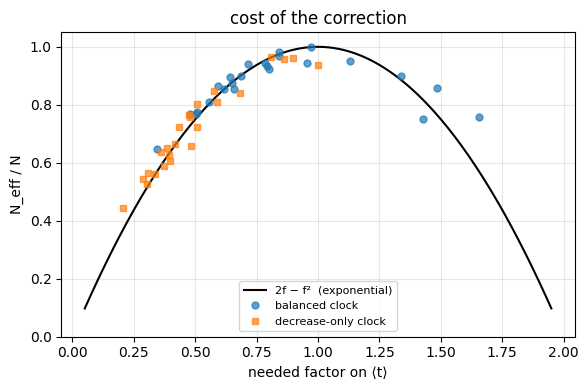

In [5]:
f_grid = np.linspace(0.05, 1.95, 200)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(f_grid, mt.neff_fraction(f_grid), "k-", label="2f − f²  (exponential)")
for clock_name, marker in (("balanced", "o"), ("decrease-only", "s")):
    c = clocks[clock_name]
    fs, ne = [], []
    for n in names:
        for j, d in enumerate(("bind", "unbind")):
            t = BY_NAME[n]["t_bind"] if d == "bind" else BY_NAME[n]["t_unbind"]
            fac = A[n][j] / c
            fs.append(fac)
            ne.append(mt.diagnostics(t, mt.target_weights(t, t.mean() * fac),
                                     t.mean() * fac)["neff"] / t.size)
    ax.plot(fs, ne, marker, ms=5, alpha=0.7, label=f"{clock_name} clock")
ax.set_xlabel("needed factor on ⟨t⟩"); ax.set_ylabel("N_eff / N"); ax.set_ylim(0, 1.05)
ax.legend(fontsize=8); ax.set_title("cost of the correction"); plt.tight_layout(); plt.show()

## 5. Using the weights on a structural observable

This is the point of the exercise. For any per-trajectory descriptor O (encounter-complex lifetime, which contacts form first, how much of the mutated side-chain contact is present at the transition), compare Σ wᵢOᵢ with the plain average, and bootstrap over trajectories for an error bar.

The descriptor here is **synthetic** — a quantity correlated with the binding time, standing in for something you would compute from the structures. With real data you would read `weights_<system>_<direction>.csv` and join it to your own analysis by trajectory index.

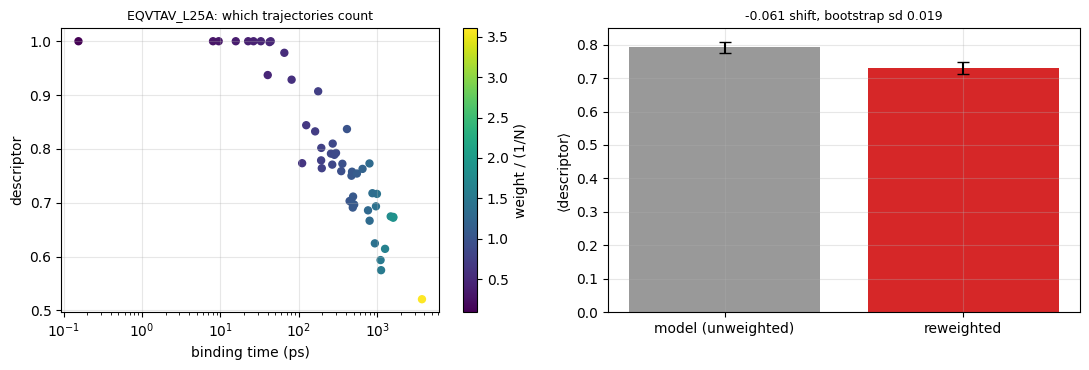

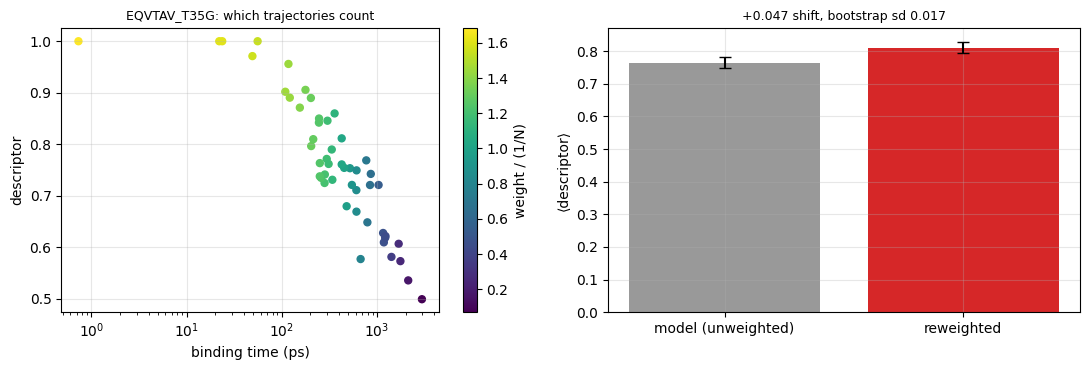

In [6]:
def descriptor(t, rng):
    # stand-in: "fraction of native contacts at the first productive encounter",
    # lower for trajectories that take longer to bind
    return np.clip(0.75 - 0.25 * np.log10(t / 400.0) + rng.normal(0, 0.05, t.size), 0, 1)

def show_observable(system="EQVTAV_L25A", nboot=200.0):
    s = BY_NAME[system]
    rng = np.random.default_rng(0)
    t = s["t_bind"]
    O = descriptor(t, rng)
    tau_target = t.mean() * A[system][0] / CLOCK
    w = mt.target_weights(t, tau_target)
    plain, wavg = O.mean(), float(np.sum(w * O))
    bs_p, bs_w = [], []
    for _ in range(int(nboot)):
        b = rng.integers(0, t.size, t.size)
        bs_p.append(O[b].mean())
        wb = w[b] / w[b].sum()
        bs_w.append(float(np.sum(wb * O[b])))
    fig, axs = plt.subplots(1, 2, figsize=(11, 3.8))
    axs[0].scatter(t, O, s=25, c=w * w.size, cmap="viridis")
    cb = plt.colorbar(axs[0].collections[0], ax=axs[0]); cb.set_label("weight / (1/N)")
    axs[0].set_xscale("log"); axs[0].set_xlabel("binding time (ps)")
    axs[0].set_ylabel("descriptor"); axs[0].set_title(f"{system}: which trajectories count", fontsize=9)
    axs[1].bar([0, 1], [plain, wavg], yerr=[np.std(bs_p), np.std(bs_w)], capsize=4,
               color=["0.6", "C3"])
    axs[1].set_xticks([0, 1]); axs[1].set_xticklabels(["model (unweighted)", "reweighted"])
    axs[1].set_ylabel("⟨descriptor⟩")
    axs[1].set_title(f"{wavg - plain:+.3f} shift, bootstrap sd {np.std(bs_w):.3f}", fontsize=9)
    plt.tight_layout(); plt.show()

explore(show_observable, static=[dict(system="EQVTAV_L25A"), dict(system="EQVTAV_T35G")],
        system=names, nboot=(50.0, 500.0, 50.0) if HAVE_WIDGETS else None)

## 6. Affinities before and after

Matching both directions per system fixes K_D = k_off/k_on by construction, so the scatter against experiment collapses onto the diagonal. The interesting part is not this plot — it is that the weights doing so are mild (§4), i.e. the experimental affinities are reachable *within* the mechanisms the model already samples.

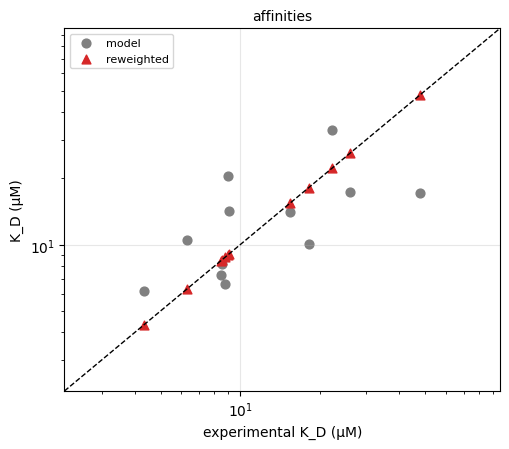

mean |log10 K_D error|:  model 0.19  ->  reweighted 0.00


In [7]:
kd_exp, kd_model, kd_rw = [], [], []
for n in names:
    s = BY_NAME[n]
    kd_exp.append(s["koff"] / s["kon"])
    kon_m, koff_m = mt.model_rates(s, CONC, "binding")
    kd_model.append(koff_m / kon_m * 1.0)                    # model K_D in uM (clock cancels)
    fb, fu = A[n][0] / CLOCK, A[n][1] / CLOCK
    kon_rw = kon_m / fb
    koff_rw = koff_m / fu
    kd_rw.append(koff_rw / kon_rw)
kd_exp, kd_model, kd_rw = map(np.array, (kd_exp, kd_model, kd_rw))
fig, ax = plt.subplots(figsize=(5.2, 4.6))
lim = [0.5 * min(kd_exp.min(), kd_model.min()), 2 * max(kd_exp.max(), kd_model.max())]
ax.plot(lim, lim, "k--", lw=1)
ax.scatter(kd_exp, kd_model, s=40, label="model", color="0.5")
ax.scatter(kd_exp, kd_rw, s=40, label="reweighted", color="C3", marker="^")
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("experimental K_D (µM)"); ax.set_ylabel("K_D (µM)")
ax.legend(fontsize=8); ax.set_title("affinities", fontsize=10)
plt.tight_layout(); plt.show()
print("mean |log10 K_D error|:  model %.2f  ->  reweighted %.2f"
      % (np.mean(np.abs(np.log10(kd_model / kd_exp))), np.mean(np.abs(np.log10(kd_rw / kd_exp)))))

## Running it on your own data

```bash
maxcal-target systems.csv --conc 0.017 --clock balanced --out target_out
```

`systems.csv` needs `system,kon_exp,koff_exp,bind_times,unbind_times`; each times file holds one first-passage time per line, in model time units, in trajectory order. The outputs are `summary.csv` (clock residuals and diagnostics), `weights_<system>_<direction>.csv` (what you join to your structural analysis), `calibration.png` and the CDF panels.

Caveats worth repeating: the clock is assumed shared across systems (check the spread of the residual factors); reweighting shifts the weights of mechanisms the model already samples and cannot invent new ones; and a low N_eff means the experimental kinetics are *not* reachable that way, which is itself a result about the model.